In [1]:
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })


import pandas as pd

import jax

# load EOS
m_val, r_val, l_val = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
mtov = m_val.max()
r16 = np.interp(1.6, m_val, r_val)


## Calculate the light curves

In [20]:
df_narrow = pd.read_csv("kn_params_narrow.dat", sep=" ")
df_wide = pd.read_csv("kn_params_wide.dat", sep=" ")

df_gw_narrow = pd.read_csv("../gw/gw_params_narrow.dat", sep=" ")
df_gw_wide = pd.read_csv("../gw/gw_params_wide.dat", sep=" ")

In [3]:
from fiesta.inference.lightcurve_model import BullaFlux

model = BullaFlux(name='Bu2026_MLP',
                  filters=["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"])

def calculate_light_curves(df_in):

    df = df_in.copy()
    df["log10_mej_wind"] = np.maximum(df["log10_mej_wind"], -4)
    df["log10_mej_wind"] = np.minimum(df["log10_mej_wind"], -0.887)

    df["log10_mej_dyn"] = np.maximum(df["log10_mej_dyn"], -4)
    df["log10_mej_dyn"] = np.minimum(df["log10_mej_dyn"], -1.33)

    df["v_ej_dyn"] = np.maximum(df["v_ej_dyn"], 0.12)
    df["v_ej_dyn"] = np.minimum(df["v_ej_dyn"], 0.35)


    kn_parameters = ["inclination_EM", "log10_mej_dyn", "v_ej_dyn", "Ye_dyn", "log10_mej_wind", "v_ej_wind", "Ye_wind", "redshift", "luminosity_distance"]
    params = dict(zip(df[kn_parameters].columns, df[kn_parameters].T.values))
    times, mags = jax.lax.map(model.predict, params, batch_size=1000)

    return np.array(times), {key: np.array(val) for key, val in mags.items()}



times_wide, mags_wide = calculate_light_curves(df_wide)
times_narrow, mags_narrow = calculate_light_curves(df_narrow)

ERROR:2026-06-18 12:18:22,523:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/nfs/enlil/hkoehn/miniconda3/envs/nmma_x_fiesta/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/nfs/enlil/hkoehn/miniconda3/envs/nmma_x_fiesta/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/nfs/enlil/hkoehn/miniconda3/envs/nmma_x_fiesta/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to lo

In [9]:
print(np.sum(np.any(mags_wide["lssti"]<=26, axis=1)))
print(np.sum(np.any(mags_narrow["lssti"]<=26, axis=1)))

4340
11741


In [15]:
print(1 - np.mean((10**df_narrow["log10_mej_dyn"] + 10**df_narrow["log10_mej_wind"])>1e-3))
print(1 - np.mean((10**df_wide["log10_mej_dyn"] + 10**df_wide["log10_mej_wind"])>1e-3))

0.024251463926637906
0.4632195337531765


In [4]:
def average_mags(times, mag_array, redshift):
    
    mask = redshift < 1.5
    times_mean = np.geomspace(0.2, 20, 80)

    mag_array = mag_array[mask].copy()
    times = times[mask].copy()

    mags_interp = np.zeros((mag_array.shape[0],times_mean.shape[0]))

    for j in range(mag_array.shape[0]):
        mags_interp[j] = np.interp(times_mean, times[j], mag_array[j])

    mags_median = np.median(mags_interp, axis=0)
    mags_lower = np.quantile(mags_interp, q=0.14, axis=0)
    mags_upper = np.quantile(mags_interp, q=0.86, axis=0)

    return times_mean, mags_median, mags_lower, mags_upper
    

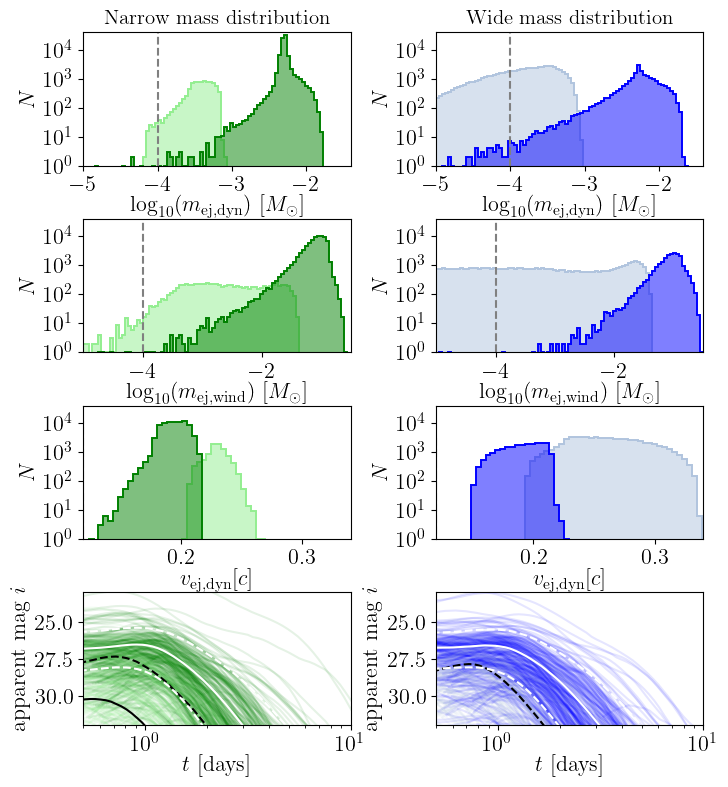

In [ ]:
def plot_kn_population(ax, df, times, mags, color, color_pc, filt="lssti"):
    pc = df["prompt_collapse"] <= 1

    ax[0].hist(df["log10_mej_dyn"][pc], bins=np.linspace(-5, -1, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.5), linewidth= 1.4, label="prompt collapse fit", rasterized=True)
    ax[0].hist(df["log10_mej_dyn"][~pc], bins=np.linspace(-5, -1, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.5), linewidth=1.4, label="NS remnant fit", rasterized=True)
    ax[0].set(xlim= (-5, -1.4), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    ax[0].vlines(model.parameter_distributions["log10_mej_dyn"][:2], *ax[0].get_ylim(), color="grey", linestyle="dashed")
    ax[0].set_xlabel("$\\log_{10}(m_{\\mathrm{ej, dyn}})$ [$M_\\odot$]", labelpad=0)
    ax[0].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[0].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))
    
    ax[1].hist(df["log10_mej_wind"][pc], bins=np.linspace(-5, -0, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.5), linewidth= 1.4, label="prompt collapse fit", rasterized=True)
    ax[1].hist(df["log10_mej_wind"][~pc], bins=np.linspace(-5, -0, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.5), linewidth= 1.4, label="NS remnant fit", rasterized=True)
    ax[1].set(xlim= (-5, -0.5), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    ax[1].vlines(model.parameter_distributions["log10_mej_wind"][:1], *ax[1].get_ylim(), color="grey", linestyle="dashed")
    ax[1].set_xlabel("$\\log_{10}(m_{\\mathrm{ej, wind}})$ [$M_\\odot$]", labelpad=0)
    ax[1].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[1].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))
    
    ax[2].hist(df["v_ej_dyn"][pc], bins=np.linspace(0.1, 0.5, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.5), linewidth= 1.4, label="prompt collapse fit", rasterized=True)
    ax[2].hist(df["v_ej_dyn"][~pc], bins=np.linspace(0.1, 0.5, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.5), linewidth= 1.4, label="NS remnant fit", rasterized=True)
    ax[2].vlines(model.parameter_distributions["v_ej_dyn"][:2], *ax[2].get_ylim(), color="grey", linestyle="dashed")
    ax[2].set(xlim= (0.12, 0.34), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    ax[2].set_xlabel("$v_{\\mathrm{ej, dyn}} [c]$", labelpad=0)
    ax[2].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[2].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))

   
    times_median, median_nopc, upper_nopc, lower_nopc = average_mags(times[~pc], mags[filt][~pc], df["redshift"][~pc])
    times_median, median_pc, upper_pc, lower_pc = average_mags(times[pc], mags[filt][pc], df["redshift"][pc])
    
    inds = np.random.choice(np.arange(mags[filt][~pc].shape[0]), replace=False, size=300)
    for ind in inds:
        ax[3].plot(times[~pc][ind], mags[filt][~pc][ind], color=color, rasterized=True, alpha=0.1)
    inds = np.random.choice(np.arange(mags[filt][pc].shape[0]), replace=False, size=300)
    for ind in inds:
        ax[3].plot(times[pc][ind], mags[filt][pc][ind], color=color_pc, rasterized=True, alpha=0.1)
    
    ax[3].plot(times_median, median_pc, color="black")
    ax[3].plot(times_median, upper_pc, color="black", linestyle="dashed")
    ax[3].plot(times_median, lower_pc, color="black", linestyle="dashed")
    ax[3].plot(times_median, median_nopc, color="lightgrey")
    ax[3].plot(times_median, upper_nopc, color="lightgrey", linestyle="dashed")
    ax[3].plot(times_median, lower_nopc, color="lightgrey", linestyle="dashed")
    
    ax[3].set(xscale="log", xlim=(0.5, 10))
    ax[3].set_xlabel("$t$ [days]", labelpad=0)
    ax[3].set_ylim((32, 23))
    ax[3].set_ylabel(f"apparent mag ${filt[-1]}$")
    ax[3].yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))


fig, ax = plt.subplots(4,2, figsize=(8, 9))
fig.subplots_adjust(hspace=0.4, wspace=0.32)

plot_kn_population(ax[:, 0], df_narrow, times_narrow, mags_narrow, color=(0., 0.5, 0), color_pc=(0.5747, 0.9333, 0.5647))
plot_kn_population(ax[:, 1], df_wide, times_wide, mags_wide, color=(0, 0, 1.0), color_pc=(0.6902, 0.7686, 0.8706))

ax[0,0].set_title("Narrow mass distribution", fontsize=15)
ax[0,1].set_title("Wide mass distribution", fontsize=15)

fig.savefig('../../figures/kn_population.pdf', dpi=250, bbox_inches="tight")

# One column figure attempt

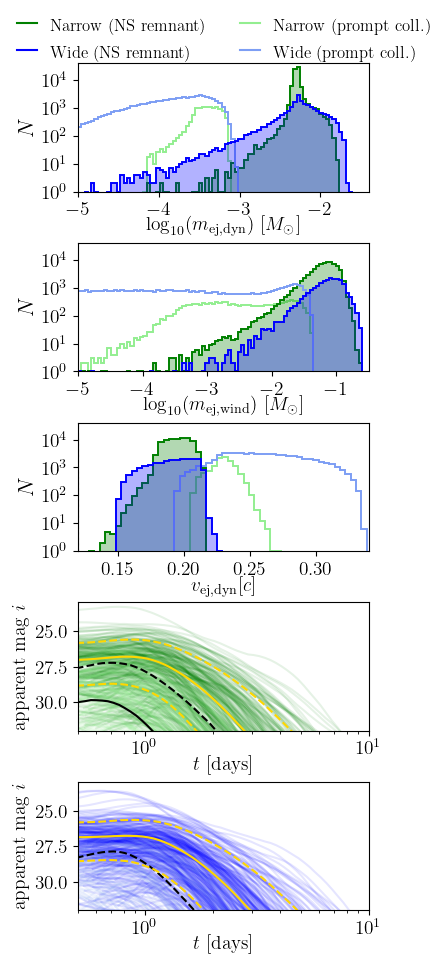

In [5]:
def plot_kn_population_one_column(ax, df, label, color, color_pc):
    pc = df["prompt_collapse"] <= 1

    ax[0].hist(df["log10_mej_dyn"][pc], bins=np.linspace(-5, -1, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.), linewidth= 1.4, rasterized=True)
    ax[0].hist(df["log10_mej_dyn"][~pc], bins=np.linspace(-5, -1, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.3), linewidth=1.4, label=label, rasterized=True)
    ax[0].set_xticks([-5, -4, -3, -2, -1], minor=False)
    ax[0].tick_params(axis="both", which="major", labelsize=14)
    ax[0].set(xlim= (-5, -1.4), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    #ax[0].vlines(model.parameter_distributions["log10_mej_dyn"][:2], *ax[0].get_ylim(), color="grey", linestyle="dashed")
    ax[0].set_xlabel("$\\log_{10}(m_{\\mathrm{ej, dyn}})$ [$M_\\odot$]", labelpad=-2, fontsize=14)
    ax[0].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[0].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))
    
    ax[1].hist(df["log10_mej_wind"][pc], bins=np.linspace(-5, -0, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.), linewidth= 1.4, rasterized=True)
    ax[1].hist(df["log10_mej_wind"][~pc], bins=np.linspace(-5, -0, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.3), linewidth= 1.4, rasterized=True)
    ax[1].set_xticks([-5, -4, -3, -2, -1], minor=False)
    ax[1].tick_params(axis="both", which="major", labelsize=14)
    ax[1].set(xlim= (-5, -0.5), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    #ax[1].vlines(model.parameter_distributions["log10_mej_wind"][:1], *ax[1].get_ylim(), color="grey", linestyle="dashed")
    ax[1].set_xlabel("$\\log_{10}(m_{\\mathrm{ej, wind}})$ [$M_\\odot$]", labelpad=-2, fontsize=14)
    ax[1].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[1].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))

    ax[2].hist(df["v_ej_dyn"][pc], bins=np.linspace(0.1, 0.5, 100), density=False, histtype="stepfilled", edgecolor=(*color_pc, 1), facecolor=(*color_pc, 0.), linewidth= 1.4, rasterized=True)
    ax[2].hist(df["v_ej_dyn"][~pc], bins=np.linspace(0.1, 0.5, 100), density=False, histtype="stepfilled", edgecolor=(*color, 1), facecolor=(*color, 0.3), linewidth= 1.4, rasterized=True)
    ax[2].vlines(model.parameter_distributions["v_ej_dyn"][:2], *ax[2].get_ylim(), color="grey", linestyle="dashed")
    ax[2].set_xticks([0.15, 0.2, 0.25, 0.3, 0.35], minor=False)
    ax[2].tick_params(axis="both", which="major", labelsize=14)
    ax[2].set(xlim= (0.12, 0.34), ylim=(1, 40_000), yscale="log", ylabel="$N$")
    ax[2].set_xlabel("$v_{\\mathrm{ej, dyn}} [c]$", labelpad=-1,fontsize=14)
    ax[2].set_yticks([1, 10, 100, 1000, 10_000], minor=False)
    ax[2].yaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs="auto"))


def plot_kn_mags(ax, df, times, mags, color, color_pc, filt="lssti"):

    pc = df["prompt_collapse"] <= 1
    times_median, median_nopc, upper_nopc, lower_nopc = average_mags(times[~pc], mags[filt][~pc], df["redshift"][~pc])
    times_median, median_pc, upper_pc, lower_pc = average_mags(times[pc], mags[filt][pc], df["redshift"][pc])
    
    inds = np.random.choice(np.arange(mags[filt][~pc].shape[0]), replace=False, size=300)
    for ind in inds:
        ax.plot(times[~pc][ind], mags[filt][~pc][ind], color=color, rasterized=True, alpha=0.1)
    inds = np.random.choice(np.arange(mags[filt][pc].shape[0]), replace=False, size=300)
    for ind in inds:
        ax.plot(times[pc][ind], mags[filt][pc][ind], color=color_pc, rasterized=True, alpha=0.1)
    
    ax.plot(times_median, median_pc, color="black")
    ax.plot(times_median, upper_pc, color="black", linestyle="dashed")
    ax.plot(times_median, lower_pc, color="black", linestyle="dashed")
    ax.plot(times_median, median_nopc, color="gold")
    ax.plot(times_median, upper_nopc, color="gold", linestyle="dashed")
    ax.plot(times_median, lower_nopc, color="gold", linestyle="dashed")

    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.set(xscale="log", xlim=(0.5, 10))
    ax.set_xlabel("$t$ [days]", labelpad=-2, fontsize=14)
    ax.set_ylim((32, 23))
    ax.set_ylabel(f"apparent mag ${filt[-1]}$", fontsize=14)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))


fig, ax = plt.subplots(5,1, figsize=(3.75, 11))
fig.subplots_adjust(hspace=0.4, wspace=0.32)

plot_kn_population_one_column(ax, df_narrow, label="Narrow", color=(0., 0.5, 0), color_pc=(0.5747, 0.9333, 0.5647))
plot_kn_population_one_column(ax, df_wide, label="Wide", color=(0, 0, 1.0), color_pc=(125/256, 159/256, 245/256))

plot_kn_mags(ax[3], df_narrow, times_narrow, mags_narrow, color=(0., 0.5, 0), color_pc=(0.5747, 0.9333, 0.5647))
plot_kn_mags(ax[4], df_wide, times_wide, mags_wide, color=(0, 0, 1.0), color_pc=(125/256, 159/256, 245/256))


lc1 = plt.plot([], [], color=(0., 0.5, 0))[0]
lc2 = plt.plot([], [], color=(0., 0., 1.))[0]
lc3 = plt.plot([], [], color=(0.5747, 0.9333, 0.5647))[0]
lc4 = plt.plot([], [], color=(125/256, 159/256, 245/256))[0]
ax[0].legend([lc1, lc2, lc3, lc4], 
             ["Narrow (NS remnant)", "Wide (NS remnant)", "Narrow (prompt coll.)", "Wide (prompt coll.)"],
             handlelength=1.2, handleheight=1.2, fontsize=12,
             bbox_to_anchor=[0.5, 0.9], loc='lower center', frameon=False, ncol=2)
fig.savefig('../../figures/kn_population.pdf', dpi=250, bbox_inches="tight")

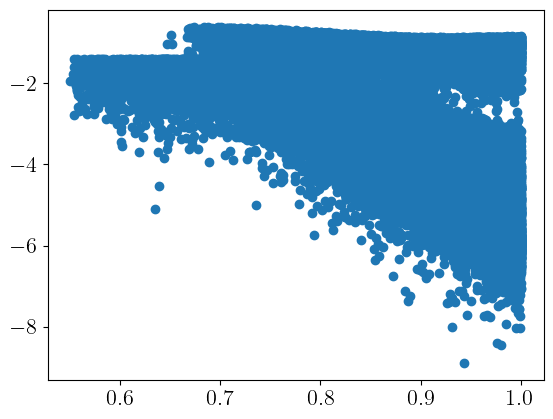

In [13]:
plt.scatter(df_gw_wide["mass_2_source"] / df_gw_wide["mass_1_source"], df_wide["log10_mej_wind"])

In [18]:
(10**df_wide["log10_mej_dyn"] + 10**df_wide["log10_mej_wind"]).max()

np.float64(0.2627814885441771)

In [21]:
(10**df_narrow["log10_mej_dyn"] + 10**df_narrow["log10_mej_wind"]).max()

np.float64(0.2475538609651468)

In [17]:
df_gw_wide.iloc[75907]

redshift               5.233190e+00
luminosity_distance    5.036435e+04
mass_1_source          1.635177e+00
mass_2_source          1.102626e+00
chi_eff                1.754666e-02
chi1_z                -2.776581e-02
chi2_z                 8.474437e-02
mass_1                 1.019237e+01
mass_2                 6.872876e+00
radius_1               1.206318e+01
radius_2               1.219907e+01
lambda_1               1.359324e+02
lambda_2               1.532383e+03
theta_jn               1.079110e+00
phase                  6.128193e+00
psi                    1.598096e+00
ra                     5.603880e+00
dec                    3.805427e-01
geocent_time           2.224122e+09
prompt_collapse        2.000000e+00
Name: 75907, dtype: float64